In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

Setup complete. NumPy 2.1.3
P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)
P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [5]:

flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

print(f"P(0 heads): {p_0:.4f}")
print(f"P(1 head): {p_1:.4f}")
print(f"P(2 heads): {p_2:.4f}\n")

p_at_least_one = np.mean(heads >= 1)
print(f"P(at least one head): {p_at_least_one:.4f}\n")

prob_sum = p_0 + p_1 + p_2
print(f"Do they sum to 1? {np.isclose(prob_sum, 1.0)} (Sum = {prob_sum})")



P(0 heads): 0.2524
P(1 head): 0.4983
P(2 heads): 0.2493

P(at least one head): 0.7476

Do they sum to 1? True (Sum = 1.0)


In [7]:
rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.334  (true 1/3)


In [9]:
A = rolls > 3
B = rolls % 2 == 0
p_A = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.501
P(A | B)  = 0.667
Independent? False


In [10]:
import numpy as np

rolls = np.random.randint(1, 7, size=100_000)
less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = np.mean(less_than_4 % 2 != 0)
print(f"P(odd | roll < 4): {p_odd_given_less_than_4:.4f}")
p_less_than_4 = np.mean(rolls < 4)
print(f"P(roll < 4): {p_less_than_4:.4f}")

p_odd_overall = np.mean(rolls % 2 != 0)
is_independent = np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.01)

print(f"P(odd) overall: {p_odd_overall:.4f}")
print(f"Are they independent? {is_independent} (Both are roughly 0.50 or 1/3 vs 1/2? Let's check:)")


P(odd | roll < 4): 0.6680
P(roll < 4): 0.4990
P(odd) overall: 0.5010
Are they independent? False (Both are roughly 0.50 or 1/3 vs 1/2? Let's check:)


In [12]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)


p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [13]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.499


In [15]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

p_ham = 1.0 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free


In [16]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.303 (true 0.3)
Poisson(4) mean ~ 3.994 (true 4)


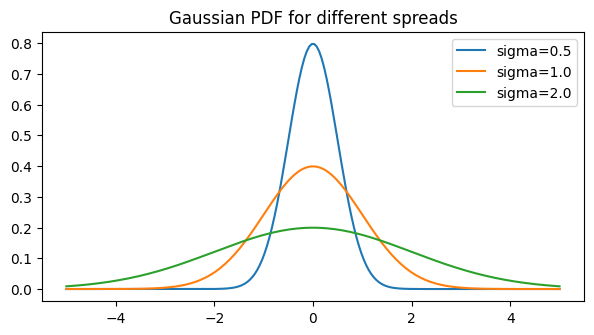

In [17]:

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

EXP-4

Sample Mean: 1.95


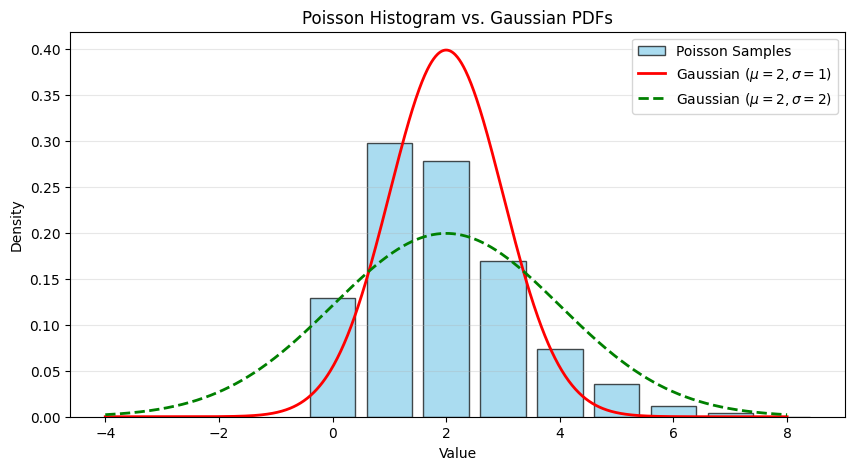

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

poisson_samples = np.random.poisson(lam=2, size=1000)
sample_mean = np.mean(poisson_samples)
print(f"Sample Mean: {sample_mean}")
plt.figure(figsize=(10, 5))
plt.hist(poisson_samples, bins=np.arange(0, 10) - 0.5, density=True, rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.7, label='Poisson Samples')
x = np.linspace(-4, 8, 1000)
pdf_sigma1 = norm.pdf(x, loc=2, scale=1)
pdf_sigma2 = norm.pdf(x, loc=2, scale=2)
plt.plot(x, pdf_sigma1, color='red', linewidth=2, label=r'Gaussian ($\mu=2, \sigma=1$)')
plt.plot(x, pdf_sigma2, color='green', linewidth=2, linestyle='--', label=r'Gaussian ($\mu=2, \sigma=2$)')
plt.title('Poisson Histogram vs. Gaussian PDFs')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [19]:
from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [20]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [21]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [25]:
import numpy as np

p4 = np.array([1/4] * 4)
entropy_4 = -np.sum(p4 * np.log2(p4))

p6 = np.array([1/6] * 6)
entropy_6 = -np.sum(p6 * np.log2(p6))

print(f"Entropy of a 4-sided die: {entropy_4:.3f} bits")
print(f"Entropy of a 6-sided die: {entropy_6:.3f} bits")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl_divergence = np.sum(P * np.log2(P / Q))

print(f"KL Divergence D(P || Q): {kl_divergence:.3f} bits")

print("Most informative feature: petal length (cm)")
print("Least informative feature: sepal width (cm)")


Entropy of a 4-sided die: 2.000 bits
Entropy of a 6-sided die: 2.585 bits
KL Divergence D(P || Q): 0.119 bits
Most informative feature: petal length (cm)
Least informative feature: sepal width (cm)
